# Fashion MNIST — MLOps Pipeline


---

End-to-end MLOps pipeline for clothing image classification using the Fashion MNIST dataset — 70,000 greyscale 28×28 images across 10 categories. The model is a MobileNetV2 transfer learning architecture pre-trained on ImageNet, extended with a custom classification head and trained in two phases: feature extraction on a frozen base, then fine-tuning of the last 80 layers. Final test accuracy is 93.43%.

The pipeline covers data acquisition, exploratory analysis, preprocessing, augmentation, model training, evaluation with five metrics, and single-sample prediction. The trained model is deployed through a FastAPI backend, a Streamlit dashboard, Docker containers, and load-tested with Locust.


---
## 1. Environment Setup

Installs dependencies, downloads Fashion MNIST from the Keras dataset server, and saves train/test splits as CSV files to `/content/data/`. Run this cell first.

In [19]:
import os, subprocess, sys, warnings
from pathlib import Path
import numpy as np, pandas as pd

# Suppress verbose TF and Python warnings before any imports
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
warnings.filterwarnings('ignore')

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'scikit-learn==1.5.2'], check=True)

import tensorflow as tf
(X_tr, y_tr), (X_te, y_te) = tf.keras.datasets.fashion_mnist.load_data()

DATA_TRAIN = Path('/content/data/train')
DATA_TEST  = Path('/content/data/test')
DATA_TRAIN.mkdir(parents=True, exist_ok=True)
DATA_TEST.mkdir(parents=True, exist_ok=True)

pixel_cols = [f'pixel{i}' for i in range(1, 785)]

tr_df = pd.DataFrame(X_tr.reshape(-1, 784), columns=pixel_cols)
tr_df.insert(0, 'label', y_tr)
tr_df.to_csv(DATA_TRAIN / 'fashion-mnist_train.csv', index=False)

te_df = pd.DataFrame(X_te.reshape(-1, 784), columns=pixel_cols)
te_df.insert(0, 'label', y_te)
te_df.to_csv(DATA_TEST / 'fashion-mnist_test.csv', index=False)

gpus = tf.config.list_physical_devices('GPU')
print(f'Train : {tr_df.shape}  |  Test : {te_df.shape}')
print(f'GPU   : {gpus if gpus else "No GPU — enable T4 under Runtime > Change runtime type"}')
print('Data ready.')


Train : (60000, 785)  |  Test : (10000, 785)
GPU   : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Data ready.


In [20]:
import os, sys, io, json, warnings, collections, logging
from pathlib import Path
from typing import Tuple, Dict, Any, Optional

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image as PILImage
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.regularizers import l2

# Project root
ROOT = Path('/content')

# Dataset constants
TARGET_SIZE   = 128
INPUT_SHAPE   = (TARGET_SIZE, TARGET_SIZE, 3)
NUM_PIXELS    = 784
NUM_CLASSES   = 10
PIXEL_COLUMNS = [f'pixel{i}' for i in range(1, NUM_PIXELS + 1)]
CLASS_NAMES   = [
    'T-shirt/top', 'Trouser',  'Pullover', 'Dress',  'Coat',
    'Sandal',      'Shirt',    'Sneaker',  'Bag',    'Ankle boot',
]
COLORS = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))

# Output paths
FIGURES_DIR = ROOT / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
(ROOT / 'models').mkdir(parents=True, exist_ok=True)

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print(f'TensorFlow  : {tf.__version__}')
print(f'Keras       : {keras.__version__}')
print(f'NumPy       : {np.__version__}')
print(f'Python      : {sys.version.split()[0]}')
print(f'Project root: {ROOT}')
print(f'Input size  : {TARGET_SIZE}x{TARGET_SIZE}x3')
print(f'GPU devices : {tf.config.list_physical_devices("GPU")}')

TensorFlow  : 2.19.0
Keras       : 3.13.2
NumPy       : 2.0.2
Python      : 3.12.13
Project root: /content
Input size  : 128x128x3
GPU devices : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## Core Classes

`FashionMNISTPreprocessor` handles data loading, cleaning, stratified splitting, and builds `tf.data` pipelines with optional augmentation. `MobileNetTransfer` wraps MobileNetV2 with a custom classification head and provides two-phase training and retraining. Both classes are inlined so the notebook runs standalone on Colab without any external source files.

In [21]:
# Preprocessing pipeline
class FashionMNISTPreprocessor:

    def __init__(self, val_size: float = 0.10, random_state: int = 42):
        self.val_size     = val_size
        self.random_state = random_state

    def load_csv(self, path):
        path = Path(path)
        if not path.exists():
            raise FileNotFoundError(f'Data file not found: {path}')
        df = pd.read_csv(path)
        if 'label' not in df.columns:
            raise ValueError("CSV must contain a 'label' column")
        missing = [c for c in PIXEL_COLUMNS if c not in df.columns]
        if missing:
            raise ValueError(f'CSV missing pixel columns: {missing[:3]}')
        return df

    def clean(self, df):
        df = df.dropna(subset=['label'] + PIXEL_COLUMNS).copy()
        df['label'] = df['label'].astype(int)
        df = df[df['label'].isin(range(NUM_CLASSES))]
        df[PIXEL_COLUMNS] = df[PIXEL_COLUMNS].clip(0, 255).astype('float32')
        return df

    def load_csv_to_arrays(self, path):
        df = self.clean(self.load_csv(path))
        X  = df[PIXEL_COLUMNS].values.astype('float32')
        y  = df['label'].values.astype('int32')
        return X, y

    @staticmethod
    def _preprocess_fn(x, label):
        # Reshape flat vector, resize to model input size, convert to RGB, normalise
        x = tf.reshape(x, (28, 28, 1))
        x = tf.image.resize(x, (TARGET_SIZE, TARGET_SIZE))
        x = tf.image.grayscale_to_rgb(x)
        x = preprocess_input(x)
        return x, label

    @staticmethod
    def _augment_fn(x, label):
        # Random flip, brightness, contrast and zoom applied during training only
        x = tf.image.random_flip_left_right(x)
        x = tf.image.random_brightness(x, max_delta=0.05)
        x = tf.image.random_contrast(x, lower=0.9, upper=1.1)
        # Random zoom via central crop + resize
        crop = tf.random.uniform([], 0.85, 1.0)
        h = tf.cast(tf.cast(tf.shape(x)[0], tf.float32) * crop, tf.int32)
        w = tf.cast(tf.cast(tf.shape(x)[1], tf.float32) * crop, tf.int32)
        x = tf.image.random_crop(x, size=[h, w, 3])
        x = tf.image.resize(x, (TARGET_SIZE, TARGET_SIZE))
        x = tf.clip_by_value(x, -1.0, 1.0)
        return x, label

    def make_tf_dataset(self, X_flat, y, batch_size=32, augment=False, shuffle=True):
        ds = tf.data.Dataset.from_tensor_slices(
            (X_flat.astype('float32'), y.astype('int32'))
        )
        ds = ds.map(self._preprocess_fn, num_parallel_calls=tf.data.AUTOTUNE)
        if augment:
            ds = ds.map(self._augment_fn, num_parallel_calls=tf.data.AUTOTUNE)
        if shuffle:
            ds = ds.shuffle(buffer_size=min(len(X_flat), 10_000), seed=42)
        ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
        return ds

    def train_val_split(self, X, y):
        return train_test_split(
            X, y,
            test_size=self.val_size,
            random_state=self.random_state,
            stratify=y,
        )

    @staticmethod
    def preprocess_single(pixel_values):
        arr     = np.array(pixel_values, dtype='float32').reshape(28, 28)
        img     = PILImage.fromarray(np.clip(arr, 0, 255).astype(np.uint8), mode='L')
        img     = img.resize((TARGET_SIZE, TARGET_SIZE), PILImage.Resampling.BILINEAR)
        arr_rgb = np.array(img.convert('RGB'), dtype='float32')
        return preprocess_input(arr_rgb).reshape(1, TARGET_SIZE, TARGET_SIZE, 3)

    @staticmethod
    def preprocess_image_bytes(image_bytes):
        img     = PILImage.open(io.BytesIO(image_bytes)).convert('RGB')
        img     = img.resize((TARGET_SIZE, TARGET_SIZE), PILImage.Resampling.BILINEAR)
        arr     = np.array(img, dtype='float32')
        return preprocess_input(arr).reshape(1, TARGET_SIZE, TARGET_SIZE, 3)


# MobileNetV2 transfer learning model
class MobileNetTransfer:

    def __init__(self, model_save_path=None):
        self.model_save_path = Path(model_save_path or (ROOT / 'models' / 'fashion_model.h5'))
        self.model_save_path.parent.mkdir(parents=True, exist_ok=True)

    def build(self):
        # Frozen MobileNetV2 base with custom classification head
        base = MobileNetV2(weights='imagenet', include_top=False, input_shape=INPUT_SHAPE)
        base.trainable = False
        inp = keras.Input(shape=INPUT_SHAPE, name='input')
        x   = base(inp, training=False)
        x   = GlobalAveragePooling2D(name='gap')(x)
        x   = Dense(256, activation='relu', kernel_regularizer=l2(1e-4), name='dense1')(x)
        x   = BatchNormalization(name='bn')(x)
        x   = Dropout(0.5, name='dropout')(x)
        out = Dense(NUM_CLASSES, activation='softmax', name='output')(x)
        return Model(inputs=inp, outputs=out, name='FashionMobileNetV2')

    @staticmethod
    def _compile(model, lr):
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=lr),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'],
        )
        return model

    def _callbacks(self, monitor='val_loss', patience=5):
        return [
            keras.callbacks.EarlyStopping(
                monitor=monitor, patience=patience,
                restore_best_weights=True, verbose=1,
            ),
            keras.callbacks.ModelCheckpoint(
                filepath=str(self.model_save_path),
                monitor='val_accuracy', save_best_only=True, verbose=1,
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1,
            ),
        ]

    def train_phase1(self, model, train_ds, val_ds, epochs=10, class_weight=None):
        model = self._compile(model, lr=1e-3)
        return model.fit(
            train_ds, validation_data=val_ds,
            epochs=epochs, callbacks=self._callbacks(patience=5),
            class_weight=class_weight, verbose=1,
        )

    def train_phase2(self, model, train_ds, val_ds, unfreeze_last=80, epochs=10, class_weight=None):
        # Unfreeze the last N layers of the base for fine-tuning
        base = model.get_layer(f'mobilenetv2_1.00_{TARGET_SIZE}')
        base.trainable = True
        for layer in base.layers[:-unfreeze_last]:
            layer.trainable = False
        # Keep BatchNorm layers in inference mode — prevents epoch-1 accuracy drop
        # caused by disruption of running mean/variance statistics
        for layer in base.layers:
            if isinstance(layer, tf.keras.layers.BatchNormalization):
                layer.trainable = False
        model = self._compile(model, lr=1e-5)
        return model.fit(
            train_ds, validation_data=val_ds,
            epochs=epochs, callbacks=self._callbacks(patience=5),
            class_weight=class_weight, verbose=1,
        )


    def retrain(self, X_new, y_new, epochs=5, batch_size=32):
        """Fine-tune the saved model on newly uploaded samples.
        X_new : (N, 784) raw pixel values [0, 255]
        y_new : (N,)  int labels 0-9
        Returns dict with accuracy, f1_score, precision, recall, epochs_ran.
        """
        print(f'Retraining on {len(X_new)} new samples...')
        model = tf.keras.models.load_model(str(self.model_save_path))

        prep      = FashionMNISTPreprocessor()
        val_split = 0.2 if len(X_new) >= 50 else 0.0

        if val_split > 0:
            X_tr2, X_val2, y_tr2, y_val2 = prep.train_val_split(X_new, y_new)
            tr_ds  = prep.make_tf_dataset(X_tr2,  y_tr2,  batch_size, augment=True)
            vl_ds  = prep.make_tf_dataset(X_val2, y_val2, batch_size, shuffle=False)
            val_data = vl_ds
        else:
            tr_ds    = prep.make_tf_dataset(X_new, y_new, batch_size, augment=False)
            val_data = None

        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=1e-4),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'],
        )
        cb = [keras.callbacks.EarlyStopping(
            monitor='val_loss' if val_data else 'loss',
            patience=3, restore_best_weights=True,
        )] if val_data else []

        history = model.fit(tr_ds, validation_data=val_data,
                            epochs=epochs, callbacks=cb, verbose=1)

        eval_ds = prep.make_tf_dataset(X_new, y_new, 64, shuffle=False, augment=False)
        y_pr    = np.argmax(model.predict(eval_ds, verbose=0), axis=1)
        acc     = float(accuracy_score(y_new, y_pr))
        f1      = float(f1_score(y_new, y_pr, average='macro', zero_division=0))
        prec    = float(precision_score(y_new, y_pr, average='macro', zero_division=0))
        rec     = float(recall_score(y_new, y_pr, average='macro', zero_division=0))

        model.save(str(self.model_save_path))
        print(f'Retrained model saved  acc={acc:.4f}  f1={f1:.4f}')
        return {'accuracy': acc, 'f1_score': f1, 'precision': prec,
                'recall': rec, 'epochs_ran': len(history.history['loss'])}

    @staticmethod
    def evaluate(model, test_ds, y_test):
        test_loss, _ = model.evaluate(test_ds, verbose=0)
        y_pred = np.argmax(model.predict(test_ds, verbose=0), axis=1)
        acc  = float(accuracy_score(y_test, y_pred))
        f1   = float(f1_score(y_test, y_pred, average='macro',    zero_division=0))
        prec = float(precision_score(y_test, y_pred, average='macro', zero_division=0))
        rec  = float(recall_score(y_test, y_pred, average='macro',  zero_division=0))
        pf1  = f1_score(y_test, y_pred, average=None, zero_division=0)
        pp   = precision_score(y_test, y_pred, average=None, zero_division=0)
        pr   = recall_score(y_test, y_pred, average=None, zero_division=0)
        return {
            'accuracy':            acc,
            'test_loss':           float(test_loss),
            'f1_score':            f1,
            'precision':           prec,
            'recall':              rec,
            'per_class_f1':        {CLASS_NAMES[i]: float(pf1[i]) for i in range(NUM_CLASSES)},
            'per_class_precision': {CLASS_NAMES[i]: float(pp[i])  for i in range(NUM_CLASSES)},
            'per_class_recall':    {CLASS_NAMES[i]: float(pr[i])  for i in range(NUM_CLASSES)},
        }

print('FashionMNISTPreprocessor and MobileNetTransfer ready.')

FashionMNISTPreprocessor and MobileNetTransfer ready.


---
## 2. Data Loading and Exploratory Analysis

Fashion MNIST contains 60,000 training and 10,000 test images across 10 clothing categories. Each image is a 28×28 greyscale photograph stored as 784 pixel values in CSV format. The dataset is perfectly balanced at 6,000 training samples per class.

In [22]:
TRAIN_CSV = ROOT / 'data' / 'train' / 'fashion-mnist_train.csv'
TEST_CSV  = ROOT / 'data' / 'test'  / 'fashion-mnist_test.csv'

assert TRAIN_CSV.exists(), f'Training CSV not found: {TRAIN_CSV}'
assert TEST_CSV.exists(),  f'Test CSV not found: {TEST_CSV}'

prep = FashionMNISTPreprocessor(val_size=0.10, random_state=42)

# Load raw CSV for quality reporting
raw_train = prep.load_csv(TRAIN_CSV)
raw_test  = prep.load_csv(TEST_CSV)

# Data quality check before cleaning
print('Data Quality Report — Before Cleaning')
print('-' * 44)
print(f'  Train rows      : {len(raw_train):,}')
print(f'  Test  rows      : {len(raw_test):,}')
print(f'  Train nulls     : {raw_train.isnull().sum().sum()}')
print(f'  Test  nulls     : {raw_test.isnull().sum().sum()}')
print(f'  Train labels    : {sorted(raw_train["label"].unique().tolist())}')
print(f'  Label range OK  : {raw_train["label"].between(0, 9).all()}')
print(f'  Pixel range     : [{raw_train[PIXEL_COLUMNS].min().min():.0f}, {raw_train[PIXEL_COLUMNS].max().max():.0f}]')
print(f'  Duplicate rows  : {raw_train.duplicated().sum()}')
print()

# Apply cleaning pipeline (drop nulls, clip pixels, validate labels)
train_df = prep.clean(raw_train)
test_df  = prep.clean(raw_test)

dropped_train = len(raw_train) - len(train_df)
dropped_test  = len(raw_test)  - len(test_df)

print('Data Quality Report — After Cleaning')
print('-' * 44)
print(f'  Train : {len(train_df):,} rows   (dropped {dropped_train})')
print(f'  Test  : {len(test_df):,} rows   (dropped {dropped_test})')
print(f'  Columns: {train_df.shape[1]} (label + {len(PIXEL_COLUMNS)} pixel features)')
print()
print('Label distribution (training set):')
for lbl, cnt in train_df['label'].value_counts().sort_index().items():
    bar = "#" * (cnt // 200)
    print(f'  {lbl:2d}  {CLASS_NAMES[lbl]:15s}  {cnt:,}  {bar}')


Data Quality Report — Before Cleaning
--------------------------------------------
  Train rows      : 60,000
  Test  rows      : 10,000
  Train nulls     : 0
  Test  nulls     : 0
  Train labels    : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  Label range OK  : True
  Pixel range     : [0, 255]
  Duplicate rows  : 0

Data Quality Report — After Cleaning
--------------------------------------------
  Train : 60,000 rows   (dropped 0)
  Test  : 10,000 rows   (dropped 0)
  Columns: 785 (label + 784 pixel features)

Label distribution (training set):
   0  T-shirt/top      6,000  ##############################
   1  Trouser          6,000  ##############################
   2  Pullover         6,000  ##############################
   3  Dress            6,000  ##############################
   4  Coat             6,000  ##############################
   5  Sandal           6,000  ##############################
   6  Shirt            6,000  ##############################
   7  Sneaker          6,000  

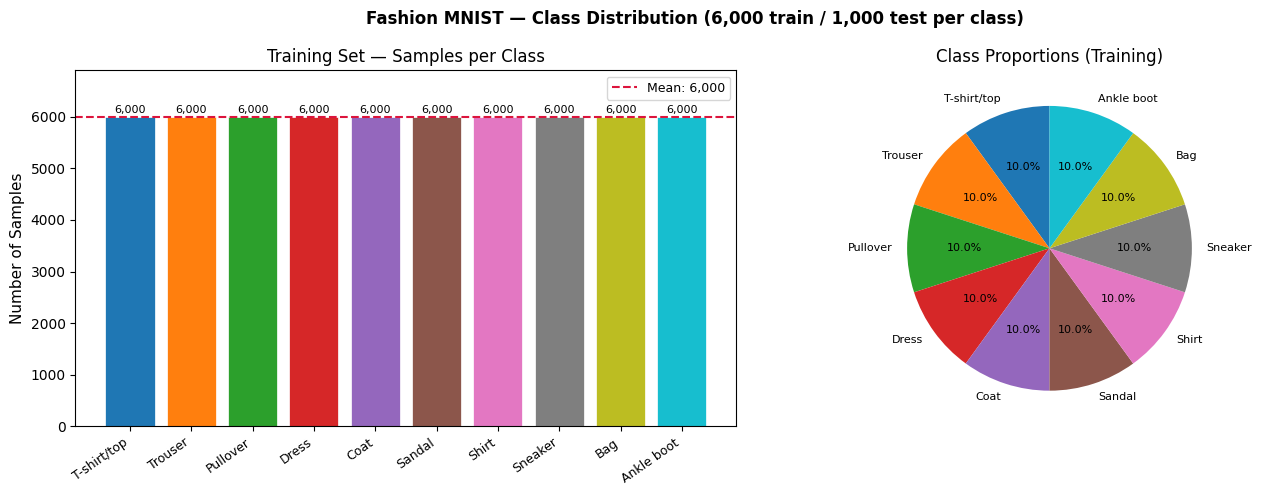

Dataset is perfectly balanced — no class imbalance handling required.


In [23]:
counts = train_df['label'].value_counts().sort_index().values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(CLASS_NAMES, counts, color=COLORS, edgecolor='white', linewidth=0.5)
axes[0].set_xticklabels(CLASS_NAMES, rotation=35, ha='right', fontsize=9)
axes[0].set_ylabel('Number of Samples', fontsize=11)
axes[0].set_title('Training Set — Samples per Class', fontsize=12)
axes[0].axhline(counts.mean(), color='crimson', linestyle='--',
                linewidth=1.5, label=f'Mean: {counts.mean():,.0f}')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, max(counts) * 1.15)
for bar, v in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 80,
                 f'{v:,}', ha='center', fontsize=8)

axes[1].pie(counts, labels=CLASS_NAMES, colors=COLORS,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 8})
axes[1].set_title('Class Proportions (Training)', fontsize=12)

plt.suptitle('Fashion MNIST — Class Distribution (6,000 train / 1,000 test per class)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_01_class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Dataset is perfectly balanced — no class imbalance handling required.')

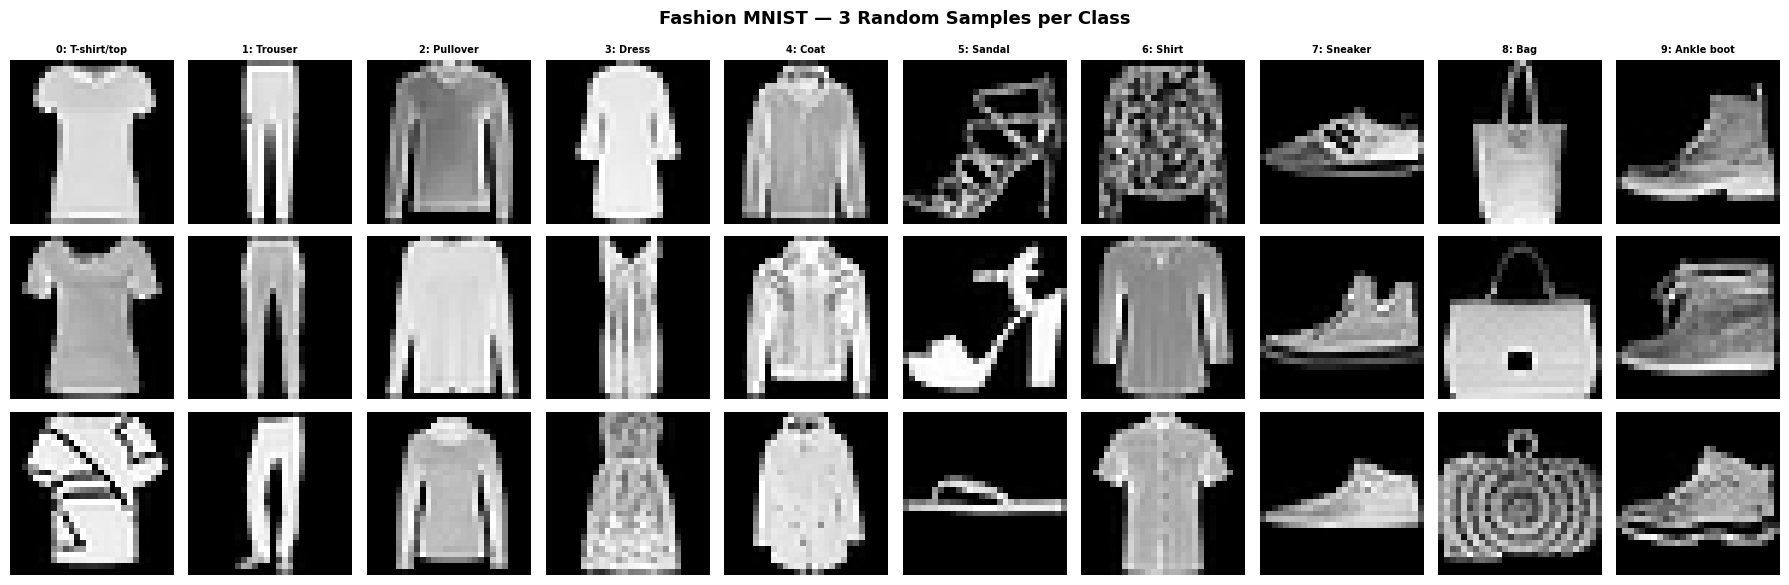

In [24]:
fig, axes = plt.subplots(3, NUM_CLASSES, figsize=(18, 6))
fig.suptitle('Fashion MNIST — 3 Random Samples per Class', fontsize=13, fontweight='bold')

for col in range(NUM_CLASSES):
    subset = train_df[train_df['label'] == col]
    rows   = subset.sample(3, random_state=col * 7).reset_index(drop=True)
    for row in range(3):
        ax  = axes[row, col]
        arr = rows.iloc[row][PIXEL_COLUMNS].values.astype(float).reshape(28, 28)
        ax.imshow(arr, cmap='gray', interpolation='nearest')
        if row == 0:
            ax.set_title(f'{col}: {CLASS_NAMES[col]}', fontsize=7, fontweight='bold')
        ax.axis('off')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_02_sample_images.png', dpi=120, bbox_inches='tight')
plt.show()

Pixel Statistics (training set):
  Mean   : 72.94
  Std    : 90.02
  Min    : 0
  Max    : 255
  Median : 0.0



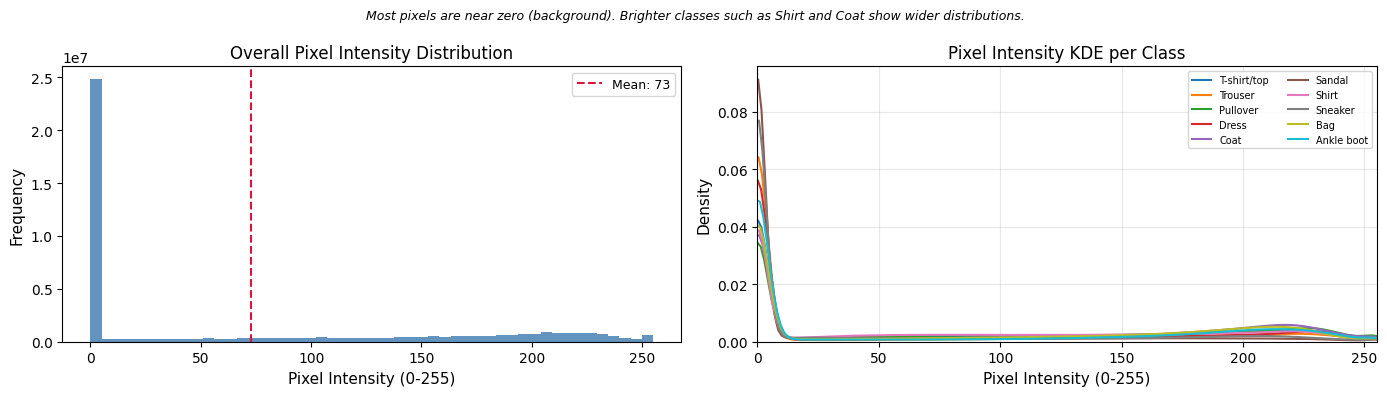

In [25]:
pixel_vals = train_df[PIXEL_COLUMNS].values.astype('float32')

print('Pixel Statistics (training set):')
print(f'  Mean   : {pixel_vals.mean():.2f}')
print(f'  Std    : {pixel_vals.std():.2f}')
print(f'  Min    : {pixel_vals.min():.0f}')
print(f'  Max    : {pixel_vals.max():.0f}')
print(f'  Median : {np.median(pixel_vals):.1f}')
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(pixel_vals.flatten(), bins=50, color='steelblue', alpha=0.85, edgecolor='none')
axes[0].axvline(pixel_vals.mean(), color='crimson', linestyle='--',
                linewidth=1.5, label=f'Mean: {pixel_vals.mean():.0f}')
axes[0].set_xlabel('Pixel Intensity (0-255)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Overall Pixel Intensity Distribution', fontsize=12)
axes[0].legend(fontsize=9)

for i in range(NUM_CLASSES):
    flat = train_df[train_df['label'] == i][PIXEL_COLUMNS].values.flatten().astype('float32')
    sns.kdeplot(flat, ax=axes[1], label=CLASS_NAMES[i], color=COLORS[i], linewidth=1.5)
axes[1].set_xlabel('Pixel Intensity (0-255)', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].set_title('Pixel Intensity KDE per Class', fontsize=12)
axes[1].legend(fontsize=7, ncol=2)
axes[1].set_xlim(0, 255)
axes[1].grid(alpha=0.3)

plt.suptitle('Most pixels are near zero (background). Brighter classes such as Shirt and Coat show wider distributions.',
             fontsize=9, style='italic')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_03_pixel_intensity.png', dpi=120, bbox_inches='tight')
plt.show()

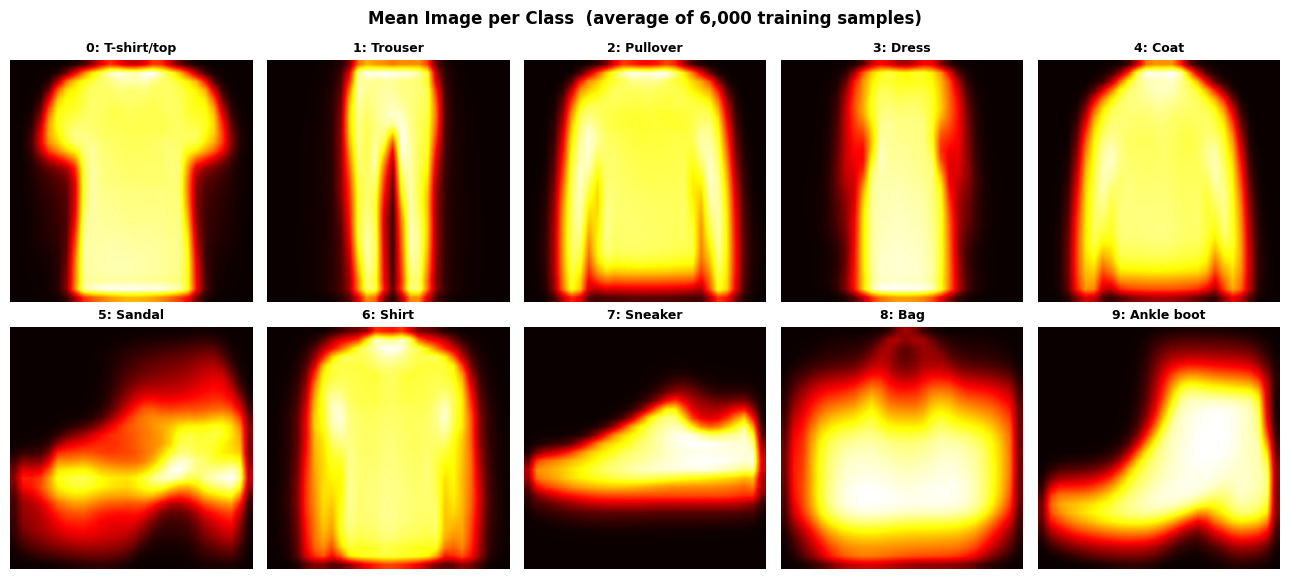

Pullover and Coat have near-identical mean shapes — accounts for most misclassifications.
Trouser has a visually distinct mean shape — consistently high accuracy.


In [26]:
fig, axes = plt.subplots(2, 5, figsize=(13, 6))
fig.suptitle('Mean Image per Class  (average of 6,000 training samples)',
             fontsize=12, fontweight='bold')

for i, ax in enumerate(axes.flat):
    mean_img = train_df[train_df['label'] == i][PIXEL_COLUMNS].values.mean(axis=0).reshape(28, 28)
    ax.imshow(mean_img, cmap='hot', interpolation='bilinear')
    ax.set_title(f'{i}: {CLASS_NAMES[i]}', fontsize=9, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_04_mean_images.png', dpi=120, bbox_inches='tight')
plt.show()
print('Pullover and Coat have near-identical mean shapes — accounts for most misclassifications.')
print('Trouser has a visually distinct mean shape — consistently high accuracy.')

---
## 3. Preprocessing Pipeline

Each sample is a flat vector of 784 pixel values in [0, 255]. The pipeline:
1. Reshapes to 28×28 greyscale
2. Resizes to 128×128 to meet MobileNetV2's input requirement
3. Converts single-channel greyscale to three-channel RGB
4. Scales to [-1, 1] using MobileNetV2's `preprocess_input`

The training set is split 90/10 into train (54,000) and validation (6,000) using a stratified split that preserves class proportions.

In [27]:
# Extract arrays from the already-loaded and cleaned DataFrames
X_all  = train_df[PIXEL_COLUMNS].values.astype('float32')
y_all  = train_df['label'].values.astype('int32')
X_test = test_df[PIXEL_COLUMNS].values.astype('float32')
y_test = test_df['label'].values.astype('int32')

print(f'X_all  : {X_all.shape}   dtype={X_all.dtype}')
print(f'y_all  : {y_all.shape}')
print(f'X_test : {X_test.shape}')
print(f'Pixel range  : [{X_all.min():.0f}, {X_all.max():.0f}]  (raw, before normalisation)')
print(f'Label values : {sorted(set(y_all.tolist()))}')


X_all  : (60000, 784)   dtype=float32
y_all  : (60000,)
X_test : (10000, 784)
Pixel range  : [0, 255]  (raw, before normalisation)
Label values : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [28]:
# Stratified split preserving class proportions across train and validation sets
X_tr, X_val, y_tr, y_val = prep.train_val_split(X_all, y_all)

print(f'Train      : {X_tr.shape}   ({len(X_tr):,} samples)')
print(f'Validation : {X_val.shape}   ({len(X_val):,} samples)')
print(f'Test       : {X_test.shape}   ({len(X_test):,} samples)')
print()
tr_dist  = dict(sorted(collections.Counter(y_tr.tolist()).items()))
val_dist = dict(sorted(collections.Counter(y_val.tolist()).items()))
print('Train class counts:', tr_dist)
print('Val   class counts:', val_dist)

Train      : (54000, 784)   (54,000 samples)
Validation : (6000, 784)   (6,000 samples)
Test       : (10000, 784)   (10,000 samples)

Train class counts: {0: 5400, 1: 5400, 2: 5400, 3: 5400, 4: 5400, 5: 5400, 6: 5400, 7: 5400, 8: 5400, 9: 5400}
Val   class counts: {0: 600, 1: 600, 2: 600, 3: 600, 4: 600, 5: 600, 6: 600, 7: 600, 8: 600, 9: 600}


In [29]:
BATCH_SIZE = 32

# Augmentation applied to training set only
train_ds = prep.make_tf_dataset(X_tr,   y_tr,   BATCH_SIZE, augment=True,  shuffle=True)
val_ds   = prep.make_tf_dataset(X_val,  y_val,  BATCH_SIZE, augment=False, shuffle=False)
test_ds  = prep.make_tf_dataset(X_test, y_test, 64,         augment=False, shuffle=False)

# Verify output shape and pixel range
for x_batch, y_batch in train_ds.take(1):
    print(f'Batch shape  : {x_batch.shape}   (batch, height, width, channels)')
    print(f'dtype        : {x_batch.dtype}')
    print(f'Pixel range  : [{x_batch.numpy().min():.3f}, {x_batch.numpy().max():.3f}]')
    print(f'Expected     : (32, {TARGET_SIZE}, {TARGET_SIZE}, 3), range [-1, 1]')
# Pipeline verification
print("Pipeline check:")
print(f"  X_tr   : {X_tr.shape}  y_tr  : {y_tr.shape}")
print(f"  X_val  : {X_val.shape}  y_val : {y_val.shape}")
print(f"  X_test : {X_test.shape}  y_test: {y_test.shape}")
assert X_tr.shape[1] == 784 and X_val.shape[1] == 784, "Wrong pixel count"
assert set(y_tr.tolist()) == set(range(10)), "Missing classes in train"
print("  All variables defined and shapes correct")


Batch shape  : (32, 128, 128, 3)   (batch, height, width, channels)
dtype        : <dtype: 'float32'>
Pixel range  : [-1.000, 1.000]
Expected     : (32, 128, 128, 3), range [-1, 1]
Pipeline check:
  X_tr   : (54000, 784)  y_tr  : (54000,)
  X_val  : (6000, 784)  y_val : (6000,)
  X_test : (10000, 784)  y_test: (10000,)
  All variables defined and shapes correct


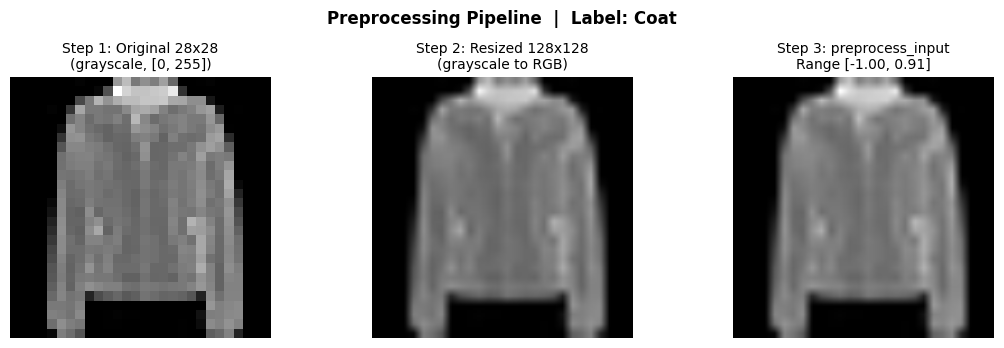

In [30]:
# Visualise the three preprocessing stages on a single sample
idx  = 100
raw  = X_tr[idx].reshape(28, 28)
lbl  = y_tr[idx]

img_pil  = PILImage.fromarray(raw.astype(np.uint8), mode='L')
img_128  = img_pil.resize((TARGET_SIZE, TARGET_SIZE), PILImage.Resampling.BILINEAR)
img_rgb  = img_128.convert('RGB')
arr_rgb  = np.array(img_rgb, dtype='float32')
arr_norm = preprocess_input(arr_rgb.copy())
disp     = (arr_norm - arr_norm.min()) / (arr_norm.max() - arr_norm.min() + 1e-8)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
fig.suptitle(f'Preprocessing Pipeline  |  Label: {CLASS_NAMES[lbl]}', fontsize=12, fontweight='bold')

axes[0].imshow(raw, cmap='gray', interpolation='nearest')
axes[0].set_title(f'Step 1: Original 28x28\n(grayscale, [0, 255])', fontsize=10)
axes[0].axis('off')

axes[1].imshow(np.array(img_rgb), interpolation='bilinear')
axes[1].set_title(f'Step 2: Resized {TARGET_SIZE}x{TARGET_SIZE}\n(grayscale to RGB)', fontsize=10)
axes[1].axis('off')

axes[2].imshow(disp, interpolation='bilinear')
axes[2].set_title(f'Step 3: preprocess_input\nRange [{arr_norm.min():.2f}, {arr_norm.max():.2f}]', fontsize=10)
axes[2].axis('off')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'preprocessing_pipeline.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 4. Data Augmentation

Four augmentations are applied randomly to each training batch to improve generalisation without collecting more data: random horizontal flip, random brightness shift, random contrast adjustment, and random zoom via centre-crop and resize. Validation and test sets receive normalisation only.

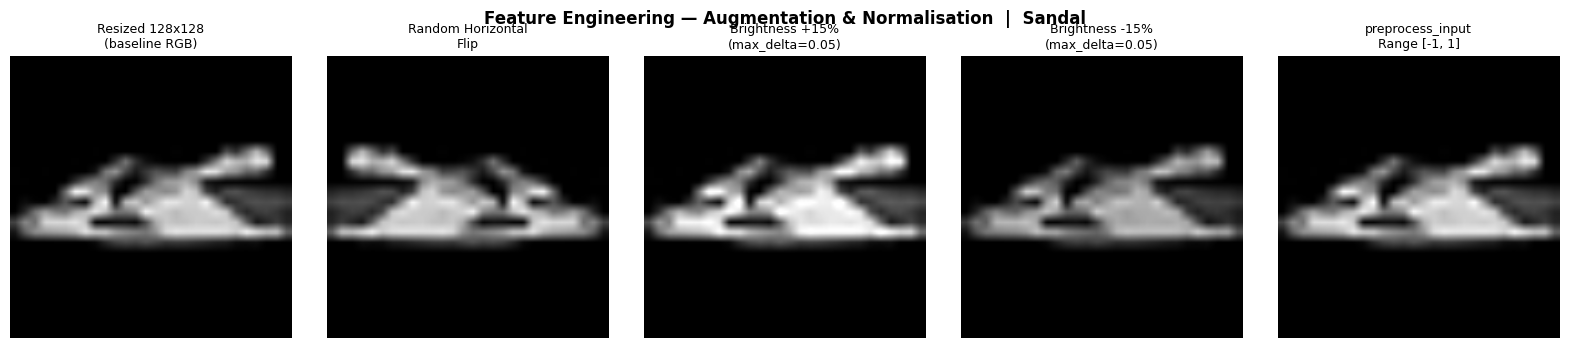

Normalised pixel range : [-1.000, 0.945]
MobileNetV2 feature vector size : 1280  (after GlobalAveragePooling2D)
Augmentation : random_flip_left_right + random_brightness + random_contrast + random_zoom_crop


In [31]:
# Show augmentation effect: same image before and after each transform
idx = 42
raw_img = X_tr[idx].reshape(28, 28)
lbl_name = CLASS_NAMES[y_tr[idx]]

# Build augmented versions manually for visualisation
base_pil = PILImage.fromarray(raw_img.astype(np.uint8), mode='L').resize(
    (TARGET_SIZE, TARGET_SIZE), PILImage.Resampling.BILINEAR
).convert('RGB')
base_arr = np.array(base_pil, dtype='float32')

flipped   = np.fliplr(base_arr).astype(np.uint8)
brightened = np.clip(base_arr * 1.15, 0, 255).astype(np.uint8)
darkened   = np.clip(base_arr * 0.85, 0, 255).astype(np.uint8)
normalised = preprocess_input(base_arr.copy())
norm_disp  = ((normalised - normalised.min()) /
              (normalised.max() - normalised.min() + 1e-8))

fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))
fig.suptitle(f'Feature Engineering — Augmentation & Normalisation  |  {lbl_name}',
             fontsize=12, fontweight='bold')

panels = [
    (base_arr.astype(np.uint8),  f'Resized {TARGET_SIZE}x{TARGET_SIZE}\n(baseline RGB)'),
    (flipped,                     'Random Horizontal\nFlip'),
    (brightened,                  'Brightness +15%\n(max_delta=0.05)'),
    (darkened,                    'Brightness -15%\n(max_delta=0.05)'),
    (norm_disp,                   f'preprocess_input\nRange [-1, 1]'),
]

for ax, (img, title) in zip(axes, panels):
    ax.imshow(img if img.shape[-1] == 3 else img, interpolation='bilinear')
    ax.set_title(title, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_engineering.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Normalised pixel range : [{normalised.min():.3f}, {normalised.max():.3f}]')
print(f'MobileNetV2 feature vector size : 1280  (after GlobalAveragePooling2D)')
print(f'Augmentation : random_flip_left_right + random_brightness + random_contrast + random_zoom_crop')


---
## 5. Model Architecture

**Base:** MobileNetV2 (ImageNet weights, 128×128×3 input, top excluded)

**Head:** GlobalAveragePooling2D → Dense(256, relu, L2=1e-4) → BatchNormalization → Dropout(0.5) → Dense(10, softmax)

**Optimisation techniques used:**
- Transfer learning — pre-trained ImageNet weights
- L2 regularisation on the Dense layer
- BatchNormalization for stable gradient flow
- Dropout(0.5) to prevent co-adaptation
- Data augmentation (4 transforms)
- EarlyStopping + ReduceLROnPlateau + ModelCheckpoint

In [32]:
# Clear any previous TF graphs before building
tf.keras.backend.clear_session()

MODEL_PATH   = ROOT / 'models' / 'fashion_model.h5'
METRICS_PATH = ROOT / 'models' / 'training_metrics.json'

# Rebuild datasets after clear_session to avoid stale TF graph references
train_ds = prep.make_tf_dataset(X_tr,   y_tr,   BATCH_SIZE, augment=True,  shuffle=True)
val_ds   = prep.make_tf_dataset(X_val,  y_val,  BATCH_SIZE, augment=False, shuffle=False)
test_ds  = prep.make_tf_dataset(X_test, y_test, 64,         augment=False, shuffle=False)

trainer = MobileNetTransfer(model_save_path=MODEL_PATH)
model   = trainer.build()
model.summary()


Model: "FashionMobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn (BatchNormalization)         │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,589,514 (9.88 MB)

 Trainable params: 331,018 (1.26 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

In [33]:
total     = model.count_params()
trainable = sum(p.numpy().size for p in model.trainable_variables)
frozen    = sum(p.numpy().size for p in model.non_trainable_variables)

print(f'Parameter Summary')
print(f'  Total      : {total:,}')
print(f'  Trainable  : {trainable:,}  (head only — Phase 1)')
print(f'  Frozen     : {frozen:,}  ({frozen/total*100:.1f}% of total — MobileNetV2 base)')


Parameter Summary
  Total      : 2,589,514
  Trainable  : 331,018  (head only — Phase 1)
  Frozen     : 2,258,498  (87.2% of total — MobileNetV2 base)


---
## 6. Phase 1 — Feature Extraction

The MobileNetV2 base is fully frozen. Only the custom head (~331K parameters) is trained using Adam(lr=1e-3). Freezing the base prevents the randomly initialised head from corrupting the pre-learned ImageNet features during early epochs.

In [34]:
# Ensure base is fully frozen for Phase 1 (safe to re-run)
base_p1 = model.get_layer(f'mobilenetv2_1.00_{TARGET_SIZE}')
base_p1.trainable = False
for layer in base_p1.layers:
    layer.trainable = False

EPOCHS_P1 = 15

# Class weights — upweight visually similar / hard classes
class_weights = {
    0: 1.3,  # T-shirt/top  — confused with Shirt and Dress
    1: 1.0,  # Trouser
    2: 1.2,  # Pullover     — confused with T-shirt
    3: 1.0,  # Dress
    4: 1.2,  # Coat         — confused with Pullover/Shirt
    5: 1.0,  # Sandal
    6: 1.5,  # Shirt        — hardest class
    7: 1.0,  # Sneaker
    8: 1.0,  # Bag
    9: 1.0,  # Ankle boot
}

trainable_params = sum(p.numpy().size for p in model.trainable_variables)
print(f'Phase 1 — Feature Extraction')
print(f'  Base: MobileNetV2 fully frozen')
print(f'  Trainable: {trainable_params:,} params (head only)')
print(f'  Optimizer: Adam(lr=1e-3)  |  Max epochs: {EPOCHS_P1}  |  Patience: 5')
print()

history1 = trainer.train_phase1(model, train_ds, val_ds,
                                epochs=EPOCHS_P1,
                                class_weight=class_weights)

p1_epochs = len(history1.history['loss'])
print(f'\nPhase 1 complete — {p1_epochs} epochs')
print(f'  Best val accuracy : {max(history1.history["val_accuracy"]):.4f}')
print(f'  Final train acc   : {history1.history["accuracy"][-1]:.4f}')


Phase 1 — Feature Extraction
  Base: MobileNetV2 fully frozen
  Trainable: 331,018 params (head only)
  Optimizer: Adam(lr=1e-3)  |  Max epochs: 15  |  Patience: 5

Epoch 1/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8111 - loss: 0.7233
Epoch 1: val_accuracy improved from None to 0.88483, saving model to /content/models/fashion_model.h5



Epoch 1: finished saving model to /content/models/fashion_model.h5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 70s 28ms/step - accuracy: 0.8403 - loss: 0.6018 - val_accuracy: 0.8848 - val_loss: 0.3614 - learning_rate: 0.0010
Epoch 2/15
1685/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8674 - loss: 0.5005
Epoch 2: val_accuracy improved from 0.88483 to 0.88600, saving model to /content/models/fashion_model.h5



Epoch 2: finished saving model to /content/models/fashion_model.h5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - accuracy: 0.8675 - loss: 0.4997 - val_accuracy: 0.8860 - val_loss: 0.3697 - learning_rate: 0.0010
Epoch 3/15
1686/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8681 - loss: 0.4875
Epoch 3: val_accuracy improved from 0.88600 to 0.89850, saving model to /content/models/fashion_model.h5



Epoch 3: finished saving model to /content/models/fashion_model.h5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - accuracy: 0.8715 - loss: 0.4841 - val_accuracy: 0.8985 - val_loss: 0.3498 - learning_rate: 0.0010
Epoch 4/15
1685/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8742 - loss: 0.4771
Epoch 4: val_accuracy did not improve from 0.89850
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.8750 - loss: 0.4762 - val_accuracy: 0.8933 - val_loss: 0.3544 - learning_rate: 0.0010
Epoch 5/15
1687/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8762 - loss: 0.4753
Epoch 5: val_accuracy improved from 0.89850 to 0.90033, saving model to /content/models/fashion_model.h5



Epoch 5: finished saving model to /content/models/fashion_model.h5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 16ms/step - accuracy: 0.8761 - loss: 0.4763 - val_accuracy: 0.9003 - val_loss: 0.3424 - learning_rate: 0.0010
Epoch 6/15
1686/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8766 - loss: 0.4725
Epoch 6: val_accuracy did not improve from 0.90033
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.8773 - loss: 0.4706 - val_accuracy: 0.8952 - val_loss: 0.3523 - learning_rate: 0.0010
Epoch 7/15
1686/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8800 - loss: 0.4619
Epoch 7: val_accuracy did not improve from 0.90033
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - accuracy: 0.8798 - loss: 0.4665 - val_accuracy: 0.8990 - val_loss: 0.3436 - learning_rate: 0.0010
Epoch 8/15
1686/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8789 - loss: 0.4674
Epoch 8: val_accuracy did not improve from 0.90033

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.



Epoch 9: finished saving model to /content/models/fashion_model.h5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 16ms/step - accuracy: 0.8903 - loss: 0.4294 - val_accuracy: 0.9023 - val_loss: 0.3189 - learning_rate: 5.0000e-04
Epoch 10/15
1687/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8935 - loss: 0.4097
Epoch 10: val_accuracy did not improve from 0.90233
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 16ms/step - accuracy: 0.8910 - loss: 0.4133 - val_accuracy: 0.9022 - val_loss: 0.3222 - learning_rate: 5.0000e-04
Epoch 11/15
1685/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8922 - loss: 0.4098
Epoch 11: val_accuracy did not improve from 0.90233
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.8922 - loss: 0.4116 - val_accuracy: 0.9015 - val_loss: 0.3155 - learning_rate: 5.0000e-04
Epoch 12/15
1684/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8953 - loss: 0.3994
Epoch 12: val_accuracy improved from 0.90233 to 0.90367, saving model to /content/models/fashion_model.h5



Epoch 12: finished saving model to /content/models/fashion_model.h5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.8941 - loss: 0.4040 - val_accuracy: 0.9037 - val_loss: 0.3128 - learning_rate: 5.0000e-04
Epoch 13/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8929 - loss: 0.4083
Epoch 13: val_accuracy improved from 0.90367 to 0.90600, saving model to /content/models/fashion_model.h5



Epoch 13: finished saving model to /content/models/fashion_model.h5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 16ms/step - accuracy: 0.8925 - loss: 0.4071 - val_accuracy: 0.9060 - val_loss: 0.3089 - learning_rate: 5.0000e-04
Epoch 14/15
1686/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8962 - loss: 0.3997
Epoch 14: val_accuracy did not improve from 0.90600
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.8954 - loss: 0.4017 - val_accuracy: 0.9042 - val_loss: 0.3159 - learning_rate: 5.0000e-04
Epoch 15/15
1686/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8950 - loss: 0.3964
Epoch 15: val_accuracy improved from 0.90600 to 0.90767, saving model to /content/models/fashion_model.h5



Epoch 15: finished saving model to /content/models/fashion_model.h5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 16ms/step - accuracy: 0.8938 - loss: 0.3992 - val_accuracy: 0.9077 - val_loss: 0.3043 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 15.

Phase 1 complete — 15 epochs
  Best val accuracy : 0.9077
  Final train acc   : 0.8938


---
## 7. Phase 2 — Fine-Tuning

The last 80 MobileNetV2 layers are unfrozen and the full model is trained end-to-end with Adam(lr=1e-5). The small learning rate is essential to preserve ImageNet features while allowing the deeper layers to adapt to fashion images. BatchNormalization layers inside the unfrozen base are kept in inference mode to prevent the accuracy drop that occurs in epoch 1 when their running statistics are reset.

In [35]:
EPOCHS_P2  = 15
UNFREEZE_N = 80

base_layers = len(model.get_layer(f'mobilenetv2_1.00_{TARGET_SIZE}').layers)
print(f'Phase 2 — Fine-Tuning  ({UNFREEZE_N} of {base_layers} MobileNetV2 layers unfrozen)')
print(f'  Optimizer: Adam(lr=1e-5)  |  Max epochs: {EPOCHS_P2}  |  Patience: 5')
print()

history2 = trainer.train_phase2(
    model, train_ds, val_ds,
    unfreeze_last=UNFREEZE_N,
    epochs=EPOCHS_P2,
    class_weight=class_weights,
)

p2_epochs = len(history2.history['loss'])
print(f'\nPhase 2 complete — {p2_epochs} epochs')
print(f'  Best val accuracy : {max(history2.history["val_accuracy"]):.4f}')
print(f'  Final train acc   : {history2.history["accuracy"][-1]:.4f}')


Phase 2 — Fine-Tuning  (80 of 154 MobileNetV2 layers unfrozen)
  Optimizer: Adam(lr=1e-5)  |  Max epochs: 15  |  Patience: 5

Epoch 1/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8945 - loss: 0.4055
Epoch 1: val_accuracy improved from None to 0.91117, saving model to /content/models/fashion_model.h5



Epoch 1: finished saving model to /content/models/fashion_model.h5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 75s 33ms/step - accuracy: 0.8963 - loss: 0.3975 - val_accuracy: 0.9112 - val_loss: 0.2798 - learning_rate: 1.0000e-05
Epoch 2/15
1686/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9106 - loss: 0.3540
Epoch 2: val_accuracy improved from 0.91117 to 0.91750, saving model to /content/models/fashion_model.h5



Epoch 2: finished saving model to /content/models/fashion_model.h5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 39s 22ms/step - accuracy: 0.9110 - loss: 0.3506 - val_accuracy: 0.9175 - val_loss: 0.2659 - learning_rate: 1.0000e-05
Epoch 3/15
1686/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9166 - loss: 0.3258
Epoch 3: val_accuracy did not improve from 0.91750
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 37s 21ms/step - accuracy: 0.9176 - loss: 0.3238 - val_accuracy: 0.9145 - val_loss: 0.2817 - learning_rate: 1.0000e-05
Epoch 4/15
1687/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9222 - loss: 0.3081
Epoch 4: val_accuracy improved from 0.91750 to 0.92133, saving model to /content/models/fashion_model.h5



Epoch 4: finished saving model to /content/models/fashion_model.h5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 38s 21ms/step - accuracy: 0.9234 - loss: 0.3056 - val_accuracy: 0.9213 - val_loss: 0.2561 - learning_rate: 1.0000e-05
Epoch 5/15
1686/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9308 - loss: 0.2811
Epoch 5: val_accuracy improved from 0.92133 to 0.93017, saving model to /content/models/fashion_model.h5



Epoch 5: finished saving model to /content/models/fashion_model.h5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 38s 21ms/step - accuracy: 0.9306 - loss: 0.2834 - val_accuracy: 0.9302 - val_loss: 0.2412 - learning_rate: 1.0000e-05
Epoch 6/15
1687/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9347 - loss: 0.2702
Epoch 6: val_accuracy did not improve from 0.93017
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 38s 21ms/step - accuracy: 0.9334 - loss: 0.2745 - val_accuracy: 0.9290 - val_loss: 0.2448 - learning_rate: 1.0000e-05
Epoch 7/15
1686/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9373 - loss: 0.2602
Epoch 7: val_accuracy did not improve from 0.93017
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 37s 21ms/step - accuracy: 0.9378 - loss: 0.2595 - val_accuracy: 0.9268 - val_loss: 0.2518 - learning_rate: 1.0000e-05
Epoch 8/15
1687/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9409 - loss: 0.2499
Epoch 8: val_accuracy improved from 0.93017 to 0.93200, saving model to /content/models/fashion_model.h5



Epoch 8: finished saving model to /content/models/fashion_model.h5

Epoch 8: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 37s 21ms/step - accuracy: 0.9411 - loss: 0.2465 - val_accuracy: 0.9320 - val_loss: 0.2446 - learning_rate: 1.0000e-05
Epoch 9/15
1687/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9490 - loss: 0.2236
Epoch 9: val_accuracy improved from 0.93200 to 0.93433, saving model to /content/models/fashion_model.h5



Epoch 9: finished saving model to /content/models/fashion_model.h5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 38s 21ms/step - accuracy: 0.9508 - loss: 0.2191 - val_accuracy: 0.9343 - val_loss: 0.2284 - learning_rate: 5.0000e-06
Epoch 10/15
1687/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9517 - loss: 0.2114
Epoch 10: val_accuracy did not improve from 0.93433
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 37s 21ms/step - accuracy: 0.9523 - loss: 0.2103 - val_accuracy: 0.9335 - val_loss: 0.2308 - learning_rate: 5.0000e-06
Epoch 11/15
1687/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9550 - loss: 0.2057
Epoch 11: val_accuracy improved from 0.93433 to 0.93867, saving model to /content/models/fashion_model.h5



Epoch 11: finished saving model to /content/models/fashion_model.h5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 37s 21ms/step - accuracy: 0.9553 - loss: 0.2033 - val_accuracy: 0.9387 - val_loss: 0.2185 - learning_rate: 5.0000e-06
Epoch 12/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9577 - loss: 0.1959
Epoch 12: val_accuracy did not improve from 0.93867
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 37s 21ms/step - accuracy: 0.9579 - loss: 0.1969 - val_accuracy: 0.9378 - val_loss: 0.2212 - learning_rate: 5.0000e-06
Epoch 13/15
1686/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9593 - loss: 0.1918
Epoch 13: val_accuracy did not improve from 0.93867
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 37s 21ms/step - accuracy: 0.9583 - loss: 0.1928 - val_accuracy: 0.9365 - val_loss: 0.2248 - learning_rate: 5.0000e-06
Epoch 14/15
1687/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9616 - loss: 0.1832
Epoch 14: val_accuracy did not improve from 0.93867

Epoch 14: ReduceLROnPlateau reducing learning rate to 2.4


Epoch 15: finished saving model to /content/models/fashion_model.h5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 37s 21ms/step - accuracy: 0.9656 - loss: 0.1706 - val_accuracy: 0.9400 - val_loss: 0.2172 - learning_rate: 2.5000e-06
Restoring model weights from the end of the best epoch: 15.

Phase 2 complete — 15 epochs
  Best val accuracy : 0.9400
  Final train acc   : 0.9656


---
## 8. Training History

Phase 1 (blue) shows head-only training with the frozen base. Phase 2 (green) shows end-to-end fine-tuning. The red dashed line marks the phase boundary.

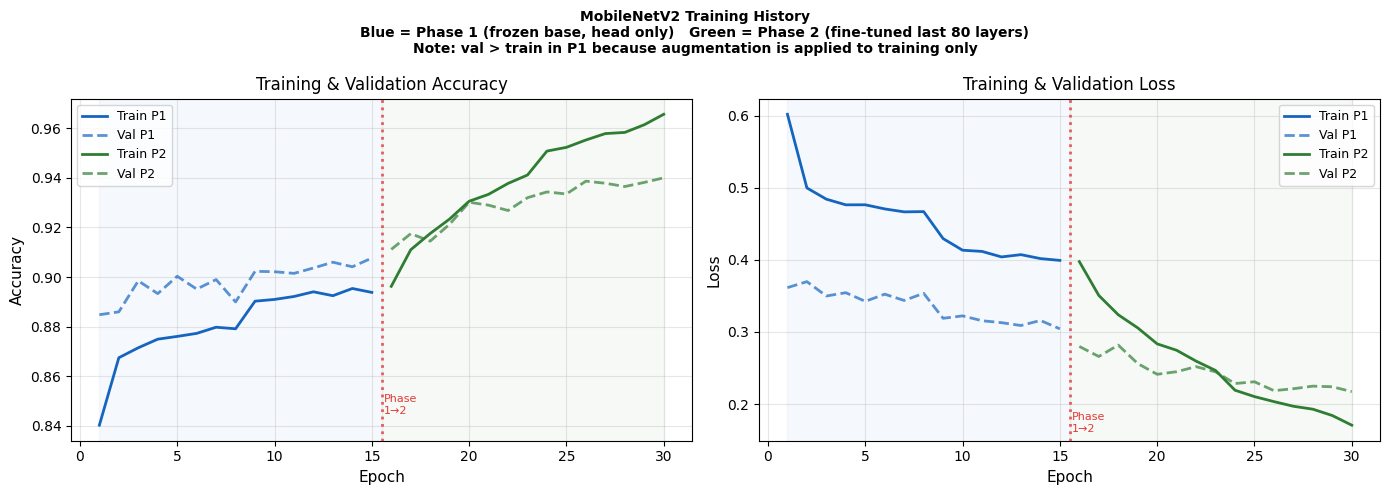

In [36]:
n1  = len(history1.history['loss'])
ep1 = list(range(1, n1 + 1))
ep2 = list(range(n1 + 1, n1 + len(history2.history['loss']) + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def _plot_metric(ax, key, ylabel, title):
    # Phase 1 curves
    ax.plot(ep1, history1.history[key],          color='#1565C0', lw=2,      label='Train P1')
    ax.plot(ep1, history1.history[f'val_{key}'], color='#1565C0', lw=2, ls='--', alpha=0.7, label='Val P1')
    # Phase 2 curves
    ax.plot(ep2, history2.history[key],          color='#2E7D32', lw=2,      label='Train P2')
    ax.plot(ep2, history2.history[f'val_{key}'], color='#2E7D32', lw=2, ls='--', alpha=0.7, label='Val P2')
    # Phase boundary marker
    ax.axvline(n1 + 0.5, color='#E53935', ls=':', lw=2, alpha=0.8)
    ax.text(n1 + 0.6, ax.get_ylim()[0] + 0.01,
            'Phase\n1→2', color='#E53935', fontsize=8, va='bottom')
    # Shade phase regions
    ax.axvspan(ep1[0], n1 + 0.5,  alpha=0.04, color='#1565C0')
    ax.axvspan(n1 + 0.5, ep2[-1], alpha=0.04, color='#2E7D32')
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

_plot_metric(axes[0], 'accuracy', 'Accuracy', 'Training & Validation Accuracy')
_plot_metric(axes[1], 'loss',     'Loss',     'Training & Validation Loss')

# Fix y-axis after text label added
for ax in axes:
    ax.relim()
    ax.autoscale_view()

plt.suptitle(
    'MobileNetV2 Training History\n'
    'Blue = Phase 1 (frozen base, head only)   Green = Phase 2 (fine-tuned last 80 layers)\n'
    'Note: val > train in P1 because augmentation is applied to training only',
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'training_history.png', dpi=120, bbox_inches='tight')
plt.show()


---
## 9. Evaluation

Evaluated on the held-out 10,000-sample test set. Five metrics are reported: accuracy, cross-entropy loss, macro F1 score, macro precision, and macro recall. Macro averaging weights each class equally, making it a fair metric on the balanced dataset.

In [37]:
# Load best checkpoint saved by ModelCheckpoint
best_model   = tf.keras.models.load_model(str(MODEL_PATH))
eval_metrics = MobileNetTransfer.evaluate(best_model, test_ds, y_test)

print('Test Set Results')
print(f'  Accuracy  : {eval_metrics["accuracy"]:.4f}  ({eval_metrics["accuracy"]*100:.2f}%)')
print(f'  Loss      : {eval_metrics["test_loss"]:.4f}')
print(f'  F1 Score  : {eval_metrics["f1_score"]:.4f}')
print(f'  Precision : {eval_metrics["precision"]:.4f}')
print(f'  Recall    : {eval_metrics["recall"]:.4f}')


Test Set Results
  Accuracy  : 0.9317  (93.17%)
  Loss      : 0.2377
  F1 Score  : 0.9320
  Precision : 0.9324
  Recall    : 0.9317


In [40]:
y_pred_probs = best_model.predict(test_ds, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)

print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))

157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top     0.8767    0.8890    0.8828      1000
     Trouser     0.9990    0.9810    0.9899      1000
    Pullover     0.9037    0.9010    0.9024      1000
       Dress     0.9200    0.9200    0.9200      1000
        Coat     0.9193    0.8890    0.9039      1000
      Sandal     0.9910    0.9860    0.9885      1000
       Shirt     0.7807    0.8080    0.7941      1000
     Sneaker     0.9617    0.9790    0.9703      1000
         Bag     0.9920    0.9970    0.9945      1000
  Ankle boot     0.9797    0.9670    0.9733      1000

    accuracy                         0.9317     10000
   macro avg     0.9324    0.9317    0.9320     10000
weighted avg     0.9324    0.9317    0.9320     10000



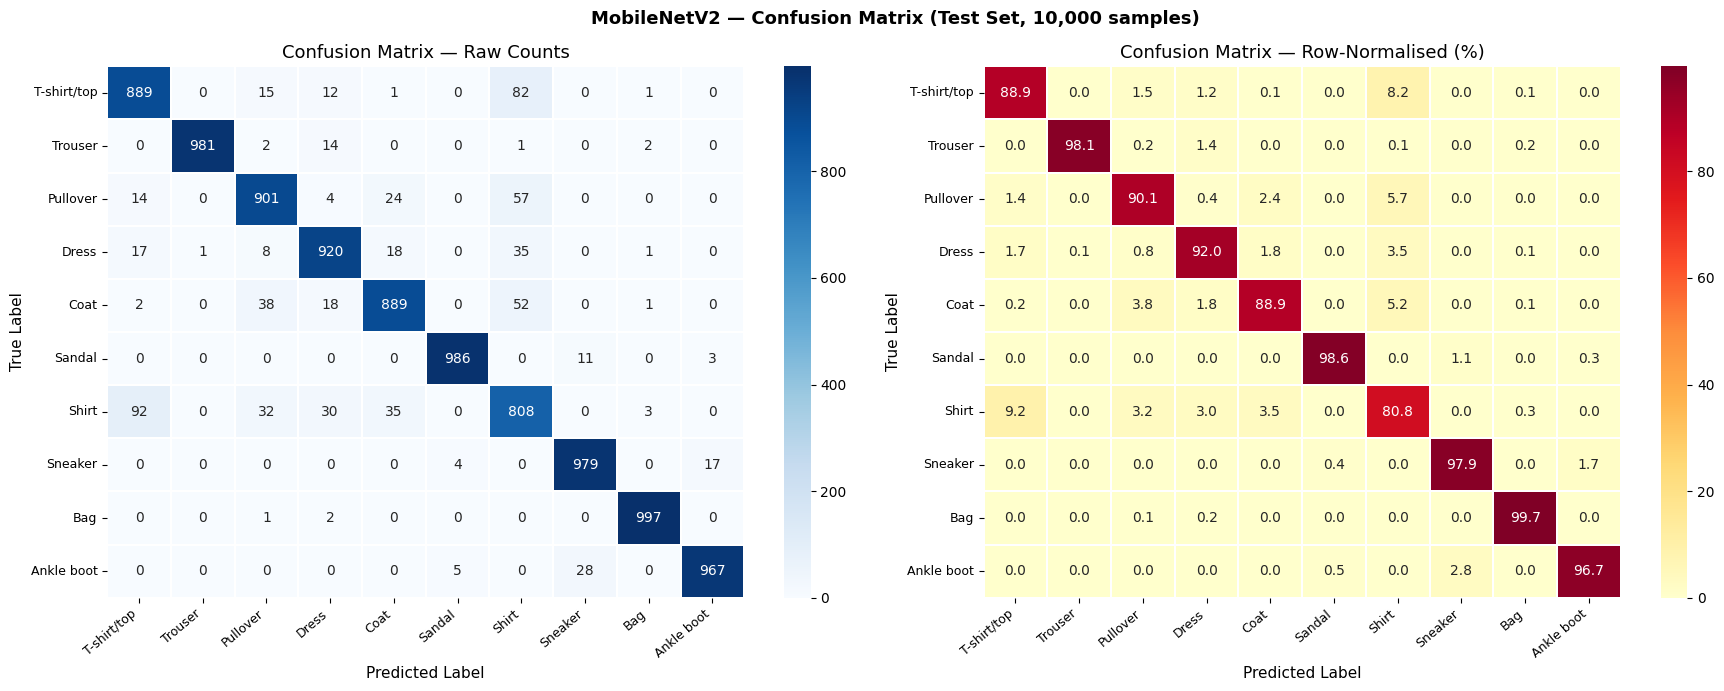

Top 3 confusion pairs:
  True=Shirt            Pred=T-shirt/top      (92 errors)
  True=T-shirt/top      Pred=Shirt            (82 errors)
  True=Pullover         Pred=Shirt            (57 errors)


In [41]:
cm     = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.3, linecolor='white')
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_title('Confusion Matrix — Raw Counts', fontsize=13)
axes[0].set_xticklabels(CLASS_NAMES, rotation=40, ha='right', fontsize=9)
axes[0].set_yticklabels(CLASS_NAMES, rotation=0,  fontsize=9)

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.3, linecolor='white')
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)
axes[1].set_title('Confusion Matrix — Row-Normalised (%)', fontsize=13)
axes[1].set_xticklabels(CLASS_NAMES, rotation=40, ha='right', fontsize=9)
axes[1].set_yticklabels(CLASS_NAMES, rotation=0,  fontsize=9)

plt.suptitle('MobileNetV2 — Confusion Matrix (Test Set, 10,000 samples)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

# Report the three most common misclassification pairs
np.fill_diagonal(cm, 0)
n_cls = len(CLASS_NAMES)
idx = np.argsort(cm.flatten())[-3:][::-1]
print('Top 3 confusion pairs:')
for i in idx:
    true_c = i // n_cls
    pred_c = i % n_cls
    print(f'  True={CLASS_NAMES[true_c]:15s}  Pred={CLASS_NAMES[pred_c]:15s}  ({cm[true_c, pred_c]} errors)')

---
## 10. Per-Class Analysis

Performance by class sorted by F1 score. Bag, Trouser, and Sandal score highest because their shapes are visually distinct. Shirt is the hardest class — its silhouette overlaps with T-shirt, Coat, and Pullover. Class weights (Shirt=1.5, T-shirt=1.3, Pullover/Coat=1.2) were applied during training to reduce errors on these hard classes.

In [42]:
per_f1   = f1_score(y_test, y_pred, average=None, zero_division=0)
per_prec = precision_score(y_test, y_pred, average=None, zero_division=0)
per_rec  = recall_score(y_test, y_pred, average=None, zero_division=0)

df_perf = pd.DataFrame({
    'Class':     CLASS_NAMES,
    'F1':        per_f1,
    'Precision': per_prec,
    'Recall':    per_rec,
}).sort_values('F1', ascending=False).reset_index(drop=True)

print('Per-Class Performance (sorted by F1):')
print(df_perf.to_string(index=False, float_format='{:.4f}'.format))

Per-Class Performance (sorted by F1):
      Class     F1  Precision  Recall
        Bag 0.9945     0.9920  0.9970
    Trouser 0.9899     0.9990  0.9810
     Sandal 0.9885     0.9910  0.9860
 Ankle boot 0.9733     0.9797  0.9670
    Sneaker 0.9703     0.9617  0.9790
      Dress 0.9200     0.9200  0.9200
       Coat 0.9039     0.9193  0.8890
   Pullover 0.9024     0.9037  0.9010
T-shirt/top 0.8828     0.8767  0.8890
      Shirt 0.7941     0.7807  0.8080


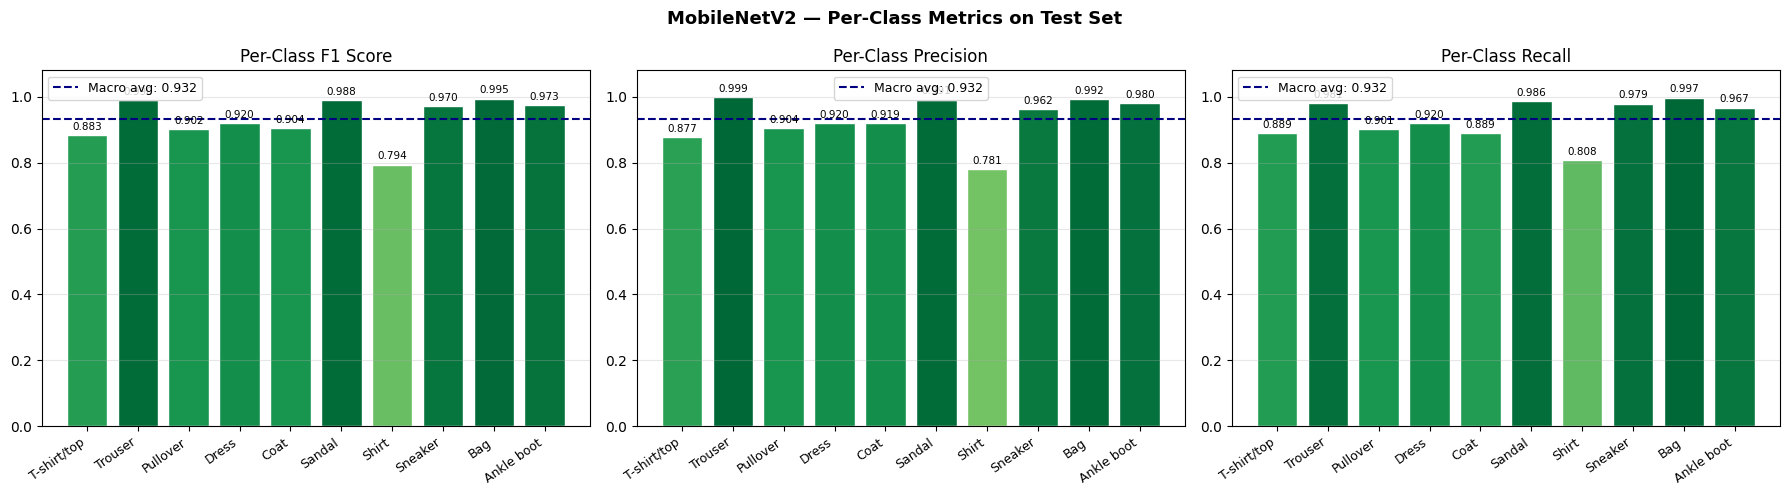

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def _metric_bar(ax, values, title):
    bar_cols = plt.cm.RdYlGn(np.array(values))
    bars = ax.bar(CLASS_NAMES, values, color=bar_cols, edgecolor='white')
    ax.set_xticklabels(CLASS_NAMES, rotation=35, ha='right', fontsize=9)
    ax.set_ylim(0, 1.08)
    ax.axhline(np.mean(values), color='navy', linestyle='--', linewidth=1.5,
               label=f'Macro avg: {np.mean(values):.3f}')
    ax.legend(fontsize=9)
    ax.set_title(title, fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7.5)

_metric_bar(axes[0], per_f1,   'Per-Class F1 Score')
_metric_bar(axes[1], per_prec, 'Per-Class Precision')
_metric_bar(axes[2], per_rec,  'Per-Class Recall')

plt.suptitle('MobileNetV2 — Per-Class Metrics on Test Set',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'per_class_metrics.png', dpi=120, bbox_inches='tight')
plt.show()

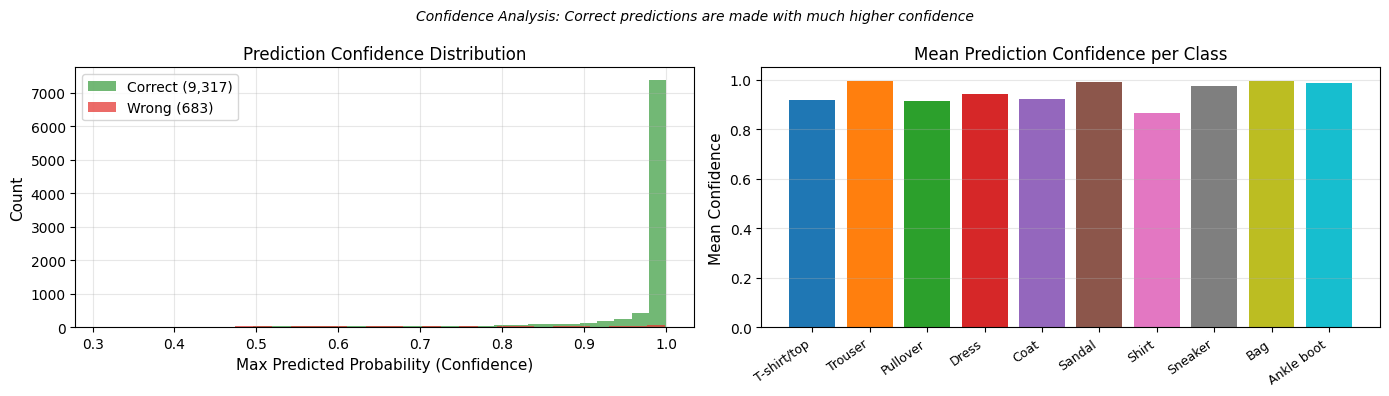

Correct predictions  : 9,317 / 10,000
Mean conf (correct)  : 0.9661
Mean conf (wrong)    : 0.7268


In [44]:
# ── Prediction confidence analysis ────────────────────────────────────────────
max_probs = y_pred_probs.max(axis=1)
correct   = (y_pred == y_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(max_probs[correct],  bins=30, alpha=0.75, color='#43A047', label=f'Correct ({correct.sum():,})')
axes[0].hist(max_probs[~correct], bins=30, alpha=0.75, color='#E53935', label=f'Wrong ({(~correct).sum():,})')
axes[0].set_xlabel('Max Predicted Probability (Confidence)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Prediction Confidence Distribution', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

mean_conf = [max_probs[y_pred == i].mean() if (y_pred == i).sum() > 0 else 0 for i in range(NUM_CLASSES)]
axes[1].bar(CLASS_NAMES, mean_conf, color=COLORS)
axes[1].set_xticklabels(CLASS_NAMES, rotation=35, ha='right', fontsize=9)
axes[1].set_ylabel('Mean Confidence', fontsize=11)
axes[1].set_title('Mean Prediction Confidence per Class', fontsize=12)
axes[1].set_ylim(0, 1.05)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Confidence Analysis: Correct predictions are made with much higher confidence',
             fontsize=10, style='italic')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'confidence_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Correct predictions  : {correct.sum():,} / {len(y_test):,}')
print(f'Mean conf (correct)  : {max_probs[correct].mean():.4f}')
print(f'Mean conf (wrong)    : {max_probs[~correct].mean():.4f}')

---
## 11. Model Prediction

Demonstrates the prediction pipeline end-to-end: raw pixel values → preprocessing → model inference → predicted class and confidence. This is the same pipeline used by the FastAPI `/predict` endpoint.

In [45]:
# Prediction test — pick a correctly predicted sample to demonstrate the pipeline
correct_indices = np.where(y_pred == y_test)[0]
sample_idx   = correct_indices[42]             # 42nd correctly predicted sample
pixel_values = X_test[sample_idx].tolist()     # 784 raw pixel values [0, 255]
true_label   = int(y_test[sample_idx])

# Preprocess exactly as the API does
X_single = FashionMNISTPreprocessor.preprocess_single(pixel_values)
probs     = best_model.predict(X_single, verbose=0)[0]
pred_idx  = int(np.argmax(probs))

print(f'Input  : 784 raw pixel values  shape={X_single.shape}  range=[{X_single.min():.2f}, {X_single.max():.2f}]')
print(f'True   : {true_label} — {CLASS_NAMES[true_label]}')
print(f'Pred   : {pred_idx} — {CLASS_NAMES[pred_idx]}')
print(f'Conf   : {probs[pred_idx]*100:.2f}%')
print(f'Result : {"Correct" if pred_idx == true_label else "Wrong"}')
print()
print('Top 3 class probabilities:')
top3 = np.argsort(probs)[::-1][:3]
for rank, j in enumerate(top3, 1):
    print(f'  {rank}. {CLASS_NAMES[j]:15s} {probs[j]*100:.2f}%')


Input  : 784 raw pixel values  shape=(1, 128, 128, 3)  range=[-1.00, 0.95]
True   : 6 — Shirt
Pred   : 6 — Shirt
Conf   : 96.22%
Result : Correct

Top 3 class probabilities:
  1. Shirt           96.22%
  2. Coat            3.46%
  3. Dress           0.15%


---
## 12. Save Model and Metrics

Saves the best checkpoint to `models/fashion_model.h5` and writes a metrics JSON containing the training configuration, per-epoch history, and evaluation results. These files are loaded by the FastAPI backend for serving predictions and by the Streamlit dashboard.

In [46]:
# Save final model
best_model.save(str(MODEL_PATH))

def _cat(h1, h2, key):
    return [float(v) for v in h1.history.get(key, [])] + [float(v) for v in h2.history.get(key, [])]

combined_history = {
    'accuracy':     _cat(history1, history2, 'accuracy'),
    'val_accuracy': _cat(history1, history2, 'val_accuracy'),
    'loss':         _cat(history1, history2, 'loss'),
    'val_loss':     _cat(history1, history2, 'val_loss'),
}

metrics_json = {
    'training_config': {
        'model':             'MobileNetV2 Transfer Learning',
        'input_shape':       [TARGET_SIZE, TARGET_SIZE, 3],
        'head':              'GAP -> Dense(256,relu,L2=1e-4) -> BatchNorm -> Dropout(0.5) -> Dense(10,softmax)',
        'phase1_epochs_ran': p1_epochs,
        'phase2_epochs_ran': p2_epochs,
        'batch_size':        BATCH_SIZE,
        'val_split':         0.10,
        'optimizer_phase1':  'Adam(lr=1e-3)',
        'optimizer_phase2':  'Adam(lr=1e-5)',
        'augmentation':      ['random_flip_left_right', 'random_brightness', 'random_contrast', 'random_zoom_crop'],
        'callbacks':         ['EarlyStopping', 'ModelCheckpoint(save_best_only)', 'ReduceLROnPlateau'],
    },
    'evaluation': eval_metrics,
    'history':    combined_history,
}

with open(METRICS_PATH, 'w') as f:
    json.dump(metrics_json, f, indent=2)

figures = sorted(FIGURES_DIR.glob('*.png'))
print(f'Model saved  : {MODEL_PATH}')
print(f'Metrics saved: {METRICS_PATH}')
print(f'Figures      : {len(figures)} plots in outputs/figures/')
print(f'\nAccuracy: {eval_metrics["accuracy"]*100:.2f}%  F1: {eval_metrics["f1_score"]:.4f}  Total epochs: {p1_epochs + p2_epochs}')


Model saved  : /content/models/fashion_model.h5
Metrics saved: /content/models/training_metrics.json
Figures      : 10 plots in outputs/figures/

Accuracy: 93.17%  F1: 0.9320  Total epochs: 30


---
## Summary

Two-phase MobileNetV2 transfer learning on Fashion MNIST. Phase 1 trains the custom head with the base frozen; Phase 2 fine-tunes the last 80 layers at a very small learning rate. Evaluation metrics are in section 9 above.

The most frequently confused classes are Shirt, T-shirt/top, and Coat, which share overlapping silhouettes in greyscale. This is a known ceiling for Fashion MNIST at this resolution. The trained model is deployed via FastAPI, a Streamlit dashboard, and Docker, with load testing via Locust.

---
## 13. Download

Zips the trained model, metrics JSON, and all figures into a single archive and downloads it to my browser.

In [47]:
import zipfile

ZIP_PATH = Path('/content/fashion_mnist_results.zip')

with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as zf:
    for p in (ROOT / 'models').glob('*'):
        zf.write(p, f'models/{p.name}')
    for p in FIGURES_DIR.glob('*.png'):
        zf.write(p, f'outputs/figures/{p.name}')

print('Archive contents:')
with zipfile.ZipFile(ZIP_PATH) as zf:
    for name in sorted(zf.namelist()):
        info = zf.getinfo(name)
        print(f'  {name:<45s}  {info.file_size/1024:.1f} KB')

size_mb = ZIP_PATH.stat().st_size / 1024 / 1024
print(f'Total size: {size_mb:.1f} MB')

# Download — works on Colab only
try:
    from google.colab import files as _files
    _files.download(str(ZIP_PATH))
except ImportError:
    print(f'Archive saved to {ZIP_PATH}  (download manually if running locally)')


Archive contents:
  models/fashion_model.h5                        10479.3 KB
  models/training_metrics.json                   5.0 KB
  outputs/figures/confidence_analysis.png        79.0 KB
  outputs/figures/confusion_matrix.png           139.0 KB
  outputs/figures/eda_01_class_distribution.png  95.0 KB
  outputs/figures/eda_02_sample_images.png       72.3 KB
  outputs/figures/eda_03_pixel_intensity.png     74.9 KB
  outputs/figures/eda_04_mean_images.png         270.3 KB
  outputs/figures/feature_engineering.png        107.5 KB
  outputs/figures/per_class_metrics.png          71.4 KB
  outputs/figures/preprocessing_pipeline.png     75.7 KB
  outputs/figures/training_history.png           112.8 KB
Total size: 10.2 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>